# Dataframe of Planetary System Data from INARA

Importing modules

In [2]:
import pandas as pd
import scipy as sp
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.metrics import r2_score, mean_squared_error

import astropy.constants as const

Unit conversions

In [3]:
Erg_to_J = 10**-7    # J per erg
cm2_to_m2 = 1/(100**2)  # m2 per cm2
parsec_to_m = 30856775814913673   # m per parsec
SolarRadii_to_m = 6.957*(10**8) # m per solar radii
AU_to_m = 149597870700 # m per AU

Function to generate Pressure-Temperature Profile. Taken from Frontier Development Labs Python code used to create the INARA dataset. The models used in these functions taken from Line et al. (2013)

In [4]:
def xi(gamma, tau):
    return (2.0/3) * (1 + (1/gamma) * (1 + (0.5*gamma*tau-1)*np.exp(-gamma*tau)) +
                        gamma*(1 - 0.5*tau**2) * sp.special.expn(2, gamma*tau)             )    

def PT_line(pressure, params, R_star, T_star, T_int, sma, grav):
    kappa  = 10**(params[0])
    gamma1 = 10**(params[1])
    gamma2 = 10**(params[2])
    alpha, beta = params[3], params[4]

    # Stellar input temperature (at top of atmosphere):
    T_irr = beta * (R_star / (2.0*sma))**0.5 * T_star

    # Gray IR optical depth:
    tau = kappa * (pressure*1e6) / grav # Convert bars to barye (CGS)

    xi1 = xi(gamma1, tau)
    xi2 = xi(gamma2, tau)

    # Temperature profile (Eq. 13 of Line et al. 2013):
    temperature = (0.75 * (T_int**4 * (2.0/3.0 + tau) +
                             T_irr**4 * (1-alpha) * xi1 +
                             T_irr**4 * alpha     * xi2 ) )**0.25

    return temperature

## Ingesting the planetary dataset

In [5]:
df = pd.read_csv('../../Raw Data/Large Validation Data/Dataset 1/psg_models.csv', index_col = 'PlanetIndex', dtype = {'PlanetIndex': str})

## Calculating Stellar and Planetary Signals for each Planet System

The spectral data provided by the INARA dataset is in (erg/s/cm2) and not per micron. The signals are thus likely the intensity of a given bin of wavelengths. These values thus only need to be summed together and not integrated.

In [6]:
for Planet in df.index:
    FileName = Planet + '.csv'
    Spectral_Data = pd.read_csv('../../Raw Data/Large Validation Data/Dataset 1/Spectra/' + FileName, usecols=['wavelength_(um)', 'stellar_signal_(erg/s/cm2)', 'planet_signal_(erg/s/cm2)'])

    Spectral_Data['stellar_signal_(erg/s/cm2)'][0:4378] = Spectral_Data['stellar_signal_(erg/s/cm2)'][0:4378]*(10**10) # At 2 μm, we assume there is a coronagraph that suppresses the  stellar signal by a factor of 10^10" Zorzan et al.

    # Bolometric signals
    Bolometric_Stellar_Signal = sum(Spectral_Data['stellar_signal_(erg/s/cm2)'].values)
    Bolometric_Stellar_Signal = Bolometric_Stellar_Signal * Erg_to_J * (1 / cm2_to_m2)

    Bolometric_Planet_Signal = sum(Spectral_Data['planet_signal_(erg/s/cm2)'].values)
    Bolometric_Planet_Signal = Bolometric_Planet_Signal * Erg_to_J * (1 / cm2_to_m2)

    df.loc[Planet, 'Bolometric Stellar Signal (W/m2)'] = Bolometric_Stellar_Signal
    df.loc[Planet, 'Bolometric Planet Signal (W/m2)'] = Bolometric_Planet_Signal

    # --- Store SA_Star in df ---
    df.loc[Planet, 'SA_Star (m2)'] = 4 * np.pi * ((df.loc[Planet, 'star_radius_in_Solar_radii'] * SolarRadii_to_m) ** 2)

    d = (   #distance between the Earth and the star
        df.loc[Planet, 'distance_from_Earth_to_the_system_in_parsecs'] * parsec_to_m
        + df.loc[Planet, 'semimajor_axis_of_the_planet_in_AU'] * AU_to_m
        + df.loc[Planet, 'planet_radius_in_km'] * 1000 * 2
    )

    df.loc[Planet, 'True Stellar Signal (W/m2)'] = (
        df.loc[Planet, 'Bolometric Stellar Signal (W/m2)'] * (4 * np.pi * (d ** 2))
    ) / df.loc[Planet, 'SA_Star (m2)']

    df.loc[Planet, 'SA_Planet (m2)'] = 4 * np.pi * ((df.loc[Planet, 'planet_radius_in_km'] * 1000) ** 2)

    d = df.loc[Planet, 'distance_from_Earth_to_the_system_in_parsecs'] * parsec_to_m # distance between planet and earth
    df.loc[Planet, 'True Planet Signal (W/m2)'] = (
        df.loc[Planet, 'Bolometric Planet Signal (W/m2)'] * (4 * np.pi * (d ** 2))
    ) / df.loc[Planet, 'SA_Planet (m2)']

    # generation of Pressure-Temperature Profiles
    P_prof = np.logspace(np.log10(df.loc[Planet, 'planet_surface_pressure_bars']), np.log10(1e-6), 50) # bar

    density = df.loc[Planet, 'planet_density']
    rplanet     = df.loc[Planet, 'planet_radius_in_km']
    mplanet = density *  (4./3. * np.pi * (rplanet * const.R_earth.cgs.value)**3) / const.M_earth.cgs.value
    surfgrav = const.G.cgs.value * mplanet * const.M_earth.cgs.value /  \
                   (rplanet * const.R_earth.cgs.value)**2
    
    T_prof = PT_line(P_prof, [df.loc[Planet, 'kappa'], df.loc[Planet, 'gamma1'], df.loc[Planet, 'gamma2'], df.loc[Planet, 'alpha'], df.loc[Planet, 'beta']], df.loc[Planet, 'star_radius_in_Solar_radii']* const.R_sun.value, df.loc[Planet, 'star_temperature_in_Kelvin'], 0, df.loc[Planet, 'semimajor_axis_of_the_planet_in_AU']* const.au.value, surfgrav) # K

    # df.loc[Planet, 'Temperature Diff (K)'] = df.loc[Planet, 'planet_surface_temperature_Kelvin'] - T_prof[0]
# df['planet_surface_temperature_Kelvin']

    df.loc[Planet, 'planet_surface_temperature_Kelvin'] = T_prof[0]

C:\Users\henry\AppData\Local\Temp\ipykernel_3288\48397470.py:5: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  Spectral_Data['stellar_signal_(erg/s/cm2)'][0:4378] = Spectral_Data['stellar_signal_(erg/s/cm2)'][0:4378]*(10**10) # At 2 μm, we as

## Removing Outliers

In [7]:
#For stars 
# SB_const =  5.670374419*(10**-8)
# df['Stellar Flux (SB) (W/m2)'] = SB_const*(df['star_temperature_in_Kelvin']**4)
# df = df.loc[df['True Stellar Signal (W/m2)'] <= 1.1*df['Stellar Flux (SB) (W/m2)']] # Removing stars that have OLR's 10% greater than their blackbodies
# df.describe().T

# # For planets
# df['Planet Flux (SB) (W/m2)'] = SB_const*(df['planet_surface_temperature_Kelvin']**4)
# df = df.loc[df['True Planet Signal (W/m2)'] <= df['Planet Flux (SB) (W/m2)']] # Removing planets that have OLR's greater than their blackbodies
# df.describe().T

Assumptions:

    No losses of electromagnetic energy from the star/planet to earth.
        Thus the electromangetic radiation experienced per m2 on earth is inversely proportional to 4*pi*d^2

# Black Body approximation for Stars

## Creation of dataframe

In [8]:
df_approx = df[['star_temperature_in_Kelvin','True Stellar Signal (W/m2)']].copy()  # Smaller dataframe containing only the data required to test the black body approximation for stars

SB_const =  5.670374419*(10**-8)            # Stefan-Boltzmann constant
df_approx['Stellar Flux (SB) (W/m2)'] = SB_const*(df_approx['star_temperature_in_Kelvin']**4)       # Approximating Stellar Flux using Stefan-Boltzmann law 

## Statistical Analysis of BlackBody approximation for Stars

The two groups are significantly different
p-value: 1.1806160498017862e-05


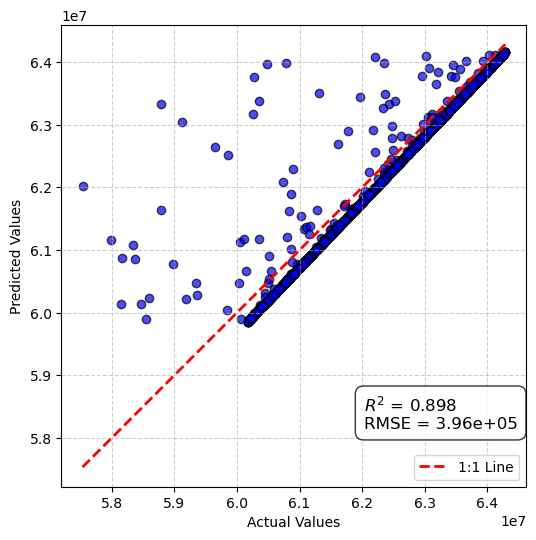

In [9]:
# Testing for Normality
Actual_Stellar_Signals = df_approx['True Stellar Signal (W/m2)']
Approximation = df_approx['Stellar Flux (SB) (W/m2)']

sA, pA = stats.normaltest(Actual_Stellar_Signals)
SB, pB = stats.normaltest(Approximation)

if pA > 0.05 and pB > 0.05:
    t, p = stats.ttest_ind(Actual_Stellar_Signals, Approximation)
else:
    MW, p = stats.mannwhitneyu(Actual_Stellar_Signals, Approximation)

if p < 0.05:
    print('The two groups are significantly different')
else:
    print('The two groups of not significantly different')

print('p-value: ' + str(p))

Rsqr = r2_score(Actual_Stellar_Signals, Approximation)
RMSE = np.sqrt(mean_squared_error(Actual_Stellar_Signals, Approximation))

# Parity Plot
plt.figure(figsize=(6,6))
plt.scatter(Actual_Stellar_Signals, Approximation, color='blue', edgecolor='k', alpha=0.7)

min_val = min(Actual_Stellar_Signals.min(), Approximation.min())
max_val = max(Actual_Stellar_Signals.max(), Approximation.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='1:1 Line')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
#plt.title('Parity Plot')
plt.legend(loc = 'lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.axis('equal')

textstr = f"$R^2$ = {Rsqr:.3g}\nRMSE = {RMSE:.3g}"

plt.text(
    0.65, 0.2, textstr,
    transform=plt.gca().transAxes,     # position relative to axes
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='black', alpha=0.8)
)


plt.show()

Thus, the black body approximation works well for stars

Thus the solar instellation experienced by a planet can simply and accurately approximated as S_(d) = SB_const*T_star^4*((4 pi R_star^2)/(4 pi d^2))

# Black Body approximation for Planets

## Creation of dataframe

In [10]:
df_approx = df[['planet_surface_temperature_Kelvin','True Planet Signal (W/m2)']].copy()  # Smaller dataframe containing only the data required to test the black body approximation for stars

SB_const =  5.670374419*(10**-8)            # Stefan-Boltzmann constant
df_approx['Planet Flux (SB) (W/m2)'] = SB_const*(df_approx['planet_surface_temperature_Kelvin']**4)       # Approximating Stellar Flux using Stefan-Boltzmann law 

## Statistical Analysis of BlackBody approximation for Planets

The two groups of not significantly different
p-value: 0.7925949543700316


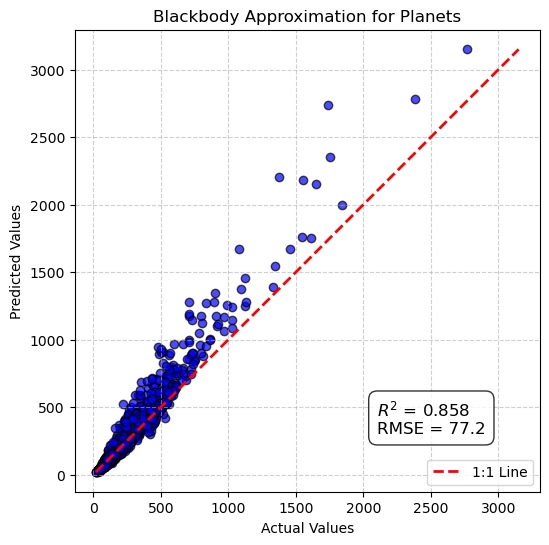

In [11]:
Actual_Planet_Signals = df_approx['True Planet Signal (W/m2)']
Approximation = df_approx['Planet Flux (SB) (W/m2)']

sA, pA = stats.normaltest(Actual_Planet_Signals)
SB, pB = stats.normaltest(Approximation)

if pA > 0.05 and pB > 0.05:
    t, p = stats.ttest_ind(Actual_Planet_Signals, Approximation)
else:
    MW, p = stats.mannwhitneyu(Actual_Planet_Signals, Approximation)

if p < 0.05:
    print('The two groups are significantly different')
else:
    print('The two groups of not significantly different')

print('p-value: ' + str(p))

Rsqr = r2_score(Actual_Planet_Signals, Approximation)
RMSE = np.sqrt(mean_squared_error(Actual_Planet_Signals, Approximation))

# Parity Plot
plt.figure(figsize=(6,6))
plt.scatter(Actual_Planet_Signals, Approximation, color='blue', edgecolor='k', alpha=0.7)

min_val = min(Actual_Planet_Signals.min(), Approximation.min())
max_val = max(Actual_Planet_Signals.max(), Approximation.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='1:1 Line')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Blackbody Approximation for Planets')
plt.legend(loc = 'lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.axis('equal')  

textstr = f"$R^2$ = {Rsqr:.3g}\nRMSE = {RMSE:.3g}"

plt.text(
    0.65, 0.2, textstr,
    transform=plt.gca().transAxes,     # position relative to axes
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='black', alpha=0.8)
)

plt.show()

Thus the Black Body approximation does not work well for planets

# Greybody approximations for planets

## Creation of Dataframe

In [12]:
df_approx = df[['planet_surface_temperature_Kelvin','True Planet Signal (W/m2)', 'planets_mean_surface_albedo']].copy()  # Smaller dataframe containing only the data required to test the black body approximation for stars

SB_const =  5.670374419*(10**-8)            # Stefan-Boltzmann constant
df_approx['Planet Flux (SB) (W/m2)'] = SB_const*(df_approx['planet_surface_temperature_Kelvin']**4)*(1-df_approx['planets_mean_surface_albedo'])       # Approximating Stellar Flux using Stefan-Boltzmann law 

## Statistical Analysis of GreyBody approximation for Planets

The two groups are significantly different
p-value: 5.997689638908386e-125


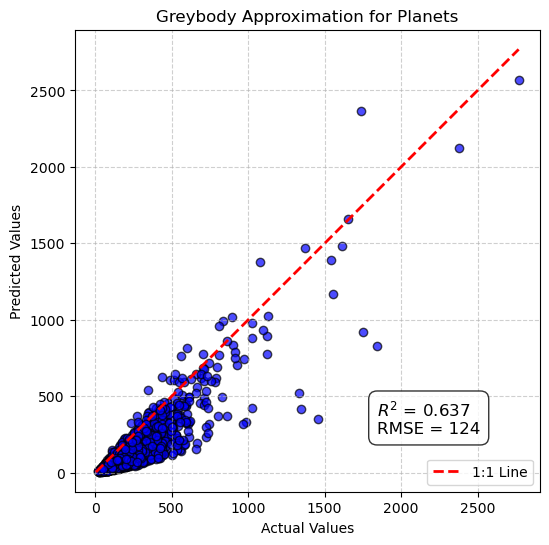

In [13]:
Actual_Planet_Signals = df_approx['True Planet Signal (W/m2)']
Approximation = df_approx['Planet Flux (SB) (W/m2)']

sA, pA = stats.normaltest(Actual_Planet_Signals)
SB, pB = stats.normaltest(Approximation)

if pA > 0.05 and pB > 0.05:
    t, p = stats.ttest_ind(Actual_Planet_Signals, Approximation)
else:
    MW, p = stats.mannwhitneyu(Actual_Planet_Signals, Approximation)

if p < 0.05:
    print('The two groups are significantly different')
else:
    print('The two groups of not significantly different')

print('p-value: ' + str(p))

Rsqr = r2_score(Actual_Planet_Signals, Approximation)
RMSE = np.sqrt(mean_squared_error(Actual_Planet_Signals, Approximation))

# Parity Plot
plt.figure(figsize=(6,6))
plt.scatter(Actual_Planet_Signals, Approximation, color='blue', edgecolor='k', alpha=0.7)

min_val = min(Actual_Planet_Signals.min(), Approximation.min())
max_val = max(Actual_Planet_Signals.max(), Approximation.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='1:1 Line')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Greybody Approximation for Planets')
plt.legend(loc = 'lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.axis('equal')  

textstr = f"$R^2$ = {Rsqr:.3g}\nRMSE = {RMSE:.3g}"

plt.text(
    0.65, 0.2, textstr,
    transform=plt.gca().transAxes,     # position relative to axes
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='black', alpha=0.8)
)

plt.show()

# Energy Balance Model

## Energy Balance Model Function

Assumes blackbody for star. Assumes blackbody for planet. Planet still reflects stellar radiation based on alpha. Assumes Radiative Equilibrium.

In [14]:
def EB(T_Star, Alpha, r_Star, d):
    S_Star = SB_const*(T_Star**4)
    
    SA_Star = 4*np.pi*(r_Star**2)
    L = S_Star*SA_Star

    S0 = L/(4*np.pi*(d**2))
    S = (1/4)*S0

    T = ((S*(1 - Alpha))/SB_const)**(1/4) # Emissivity = 1 - Reflectivity
    return T

## Implementation of Energy Balance Model

Top-of-atmosphere albedo assumed to be equal to surface albedo.

The two groups are significantly different
p-value: 0.0


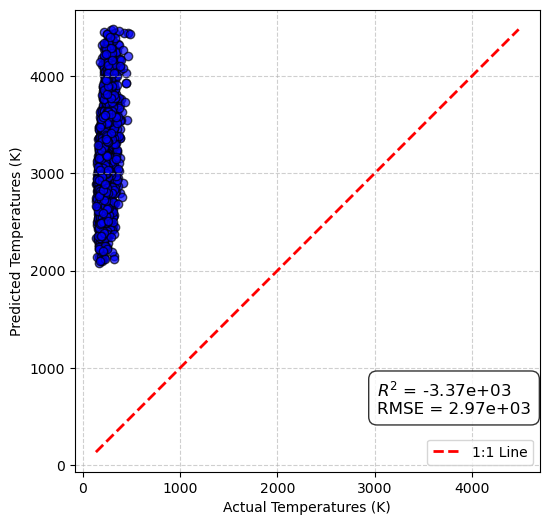

In [15]:
df_EB = df[['star_temperature_in_Kelvin', 'planets_mean_surface_albedo', 'star_radius_in_Solar_radii', 'semimajor_axis_of_the_planet_in_AU', 'planet_surface_temperature_Kelvin']].copy()

for Planet in df_EB.index:
    df_EB.loc[Planet, 'T'] = EB(df_EB.loc[Planet, 'star_temperature_in_Kelvin'], df_EB.loc[Planet, 'planets_mean_surface_albedo'], df_EB.loc[Planet, 'star_radius_in_Solar_radii'], df_EB.loc[Planet, 'semimajor_axis_of_the_planet_in_AU'])

T_actual = df_EB['planet_surface_temperature_Kelvin']
T_pred = df_EB['T']

sA, pA = stats.normaltest(T_actual)
SB, pB = stats.normaltest(T_pred)

if pA > 0.05 and pB > 0.05:
    t, p = stats.ttest_ind(T_actual, T_pred)
else:
    MW, p = stats.mannwhitneyu(T_actual, T_pred)

if p < 0.05:
    print('The two groups are significantly different')
else:
    print('The two groups of not significantly different')

print('p-value: ' + str(p))

Rsqr = r2_score(T_actual, T_pred)
RMSE = np.sqrt(mean_squared_error(T_actual, T_pred))

# Parity Plot
plt.figure(figsize=(6,6))
plt.scatter(T_actual, T_pred, color='blue', edgecolor='k', alpha=0.7)

min_val = min(T_actual.min(), T_pred.min())
max_val = max(T_actual.max(), T_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='1:1 Line')

plt.xlabel('Actual Temperatures (K)')
plt.ylabel('Predicted Temperatures (K)')
#plt.title('Parity Plot')
plt.legend(loc = 'lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.axis('equal')  

textstr = f"$R^2$ = {Rsqr:.3g}\nRMSE = {RMSE:.3g}"

plt.text(
    0.65, 0.2, textstr,
    transform=plt.gca().transAxes,     # position relative to axes
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='black', alpha=0.8)
)

plt.show()

This result suggests that INARA planets are not in radiative equilibrium.

# Checking Radiative-Equilibrium assumption

In [16]:
def CheckSS(r_Star, d, S_Star, F_Planet, Alpha):
    SA_Star = 4*np.pi*(r_Star**2)
    L = S_Star*SA_Star

    S0 = L/(4*np.pi*(d**2))
    S = (1/4)*S0

    dE_dt = S*(1-Alpha) - F_Planet
    return dE_dt

df_EB = df[['True Stellar Signal (W/m2)', 'True Planet Signal (W/m2)','planets_mean_surface_albedo', 'star_radius_in_Solar_radii', 'semimajor_axis_of_the_planet_in_AU']].copy()

for Planet in df_EB.index:
    # df_EB.loc[Planet, 'dE_dt'] = CheckSS(df_EB.loc[Planet, 'star_radius_in_Solar_radii'], df_EB.loc[Planet, 'semimajor_axis_of_the_planet_in_AU'], df_EB.loc[Planet, 'True Stellar Signal (W/m2)'], df_EB.loc[Planet, 'True Planet Signal (W/m2)'], df_EB.loc[Planet, 'planets_mean_surface_albedo'])
    df_EB.loc[Planet, 'dE_dt'] = CheckSS(df_EB.loc[Planet, 'star_radius_in_Solar_radii'], df_EB.loc[Planet, 'semimajor_axis_of_the_planet_in_AU'], df_EB.loc[Planet, 'True Stellar Signal (W/m2)'], df_EB.loc[Planet, 'True Planet Signal (W/m2)'], df_EB.loc[Planet, 'planets_mean_surface_albedo'])


df_EB['dE_dt']


PlanetIndex
0002085    7.880947e+06
0002091    5.197568e+06
0002094    7.835632e+06
0002101    6.599196e+06
0000203    4.100245e+06
               ...     
0034914    2.252255e+06
0034947    1.494985e+07
0034960    3.656091e+06
0034978    4.844949e+06
0034985    3.955102e+06
Name: dE_dt, Length: 2000, dtype: float64

Planets are not in radiative equilibrium. 